In [2]:
!pip install haversine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from haversine import haversine, Unit
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Setup Feature Engineering Selesai.")


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Devi\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Setup Feature Engineering Selesai.


In [3]:
# Ganti path ini sesuai dengan lokasi data kamu di Colab
PATH_RETAIL = "https://raw.githubusercontent.com/shineistu86/CPS-CC26/e5498e2712b24c552cade38bd4979c695e31fc30/Data%20Clean/jaksel_retail_final_v3.csv"
PATH_PASAR = "https://raw.githubusercontent.com/shineistu86/CPS-CC26/e5498e2712b24c552cade38bd4979c695e31fc30/Data%20Clean/jaksel_pasar_final.csv"

df_retail = pd.read_csv(PATH_RETAIL)
df_pasar  = pd.read_csv(PATH_PASAR)

# Bersihkan missing values pada koordinat
df_retail.dropna(subset=['latitude', 'longitude'], inplace=True)
df_pasar.dropna(subset=['latitude', 'longitude'], inplace=True)
df_retail.reset_index(drop=True, inplace=True)
df_pasar.reset_index(drop=True, inplace=True)

print(f"Data termuat: {len(df_retail)} Retail, {len(df_pasar)} Pasar")

Data termuat: 662 Retail, 23 Pasar


In [3]:
print("Menghitung fitur spasial murni...")
coords_retail = list(zip(df_retail['latitude'], df_retail['longitude']))

comp_density = []
jarak_kompetitor = []

for i, row in df_retail.iterrows():
    origin = (row['latitude'], row['longitude'])

    # 1. Density 500m (Sesama retail)
    count_500m = sum(
        1 for j, t in enumerate(coords_retail)
        if i != j and haversine(origin, t, unit=Unit.METERS) <= 500
    )
    comp_density.append(count_500m)

    # 2. Jarak ke Kompetitor Terdekat
    brand_musuh = 'Alfamart' if row['store'] == 'Indomaret' else 'Indomaret'
    df_musuh = df_retail[df_retail['store'] == brand_musuh]

    if not df_musuh.empty:
        dists = [haversine(origin, (r['latitude'], r['longitude']), unit=Unit.METERS) for _, r in df_musuh.iterrows()]
        jarak_kompetitor.append(min(dists))
    else:
        jarak_kompetitor.append(0)

df_retail['competitor_density_500m'] = comp_density
df_retail['jarak_kompetitor_meter']  = jarak_kompetitor
df_retail['kompetitor_head_to_head'] = (df_retail['jarak_kompetitor_meter'] <= 50).astype(int)

Menghitung fitur spasial murni...


Mengevaluasi jumlah klaster optimal (k)...


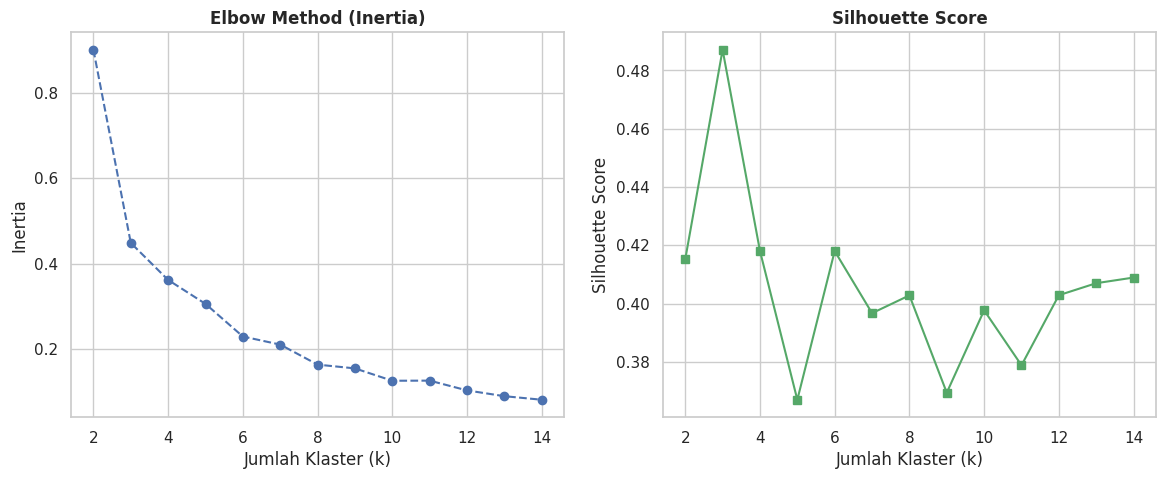

In [4]:
print("Mengevaluasi jumlah klaster optimal (k)...")
koordinat = df_retail[['latitude', 'longitude']]

inertia = []
silhouette_scores = []
K_range = range(2, 15)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(koordinat)
    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(koordinat, kmeans_test.labels_))

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(K_range, inertia, marker='o', linestyle='--', color='b')
ax[0].set_title('Elbow Method (Inertia)', fontweight='bold')
ax[0].set_xlabel('Jumlah Klaster (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax[1].set_title('Silhouette Score', fontweight='bold')
ax[1].set_xlabel('Jumlah Klaster (k)')
ax[1].set_ylabel('Silhouette Score')
plt.show()

In [5]:
BEST_K = 3
print(f"Mengaplikasikan K-Means dengan k={BEST_K}...")
kmeans_final = KMeans(n_clusters=BEST_K, random_state=42)
df_retail['zona_kmeans'] = kmeans_final.fit_predict(koordinat)

# Membuat Label Target
jarak_pasar = []
for _, mini in df_retail.iterrows():
    origin = (mini['latitude'], mini['longitude'])
    distances = df_pasar.apply(
        lambda p: haversine(origin, (p['latitude'], p['longitude']), unit=Unit.METERS), axis=1)
    jarak_pasar.append(distances.min())

# Target: 1 jika jarak ke pasar <= 500m (Pelanggaran)
df_retail['pelanggaran_zonasi'] = (pd.Series(jarak_pasar) <= 500).astype(int)

# HANYA SIMPAN FITUR YANG AMAN DARI LEAKAGE
COLS_TO_EXPORT = [
    'latitude', 'longitude', 'competitor_density_500m',
    'jarak_kompetitor_meter', 'kompetitor_head_to_head',
    'zona_kmeans', 'pelanggaran_zonasi'
]

OUTPUT_PATH = "Data Clean/jaksel_AI_ready_MVP.csv"
df_retail[COLS_TO_EXPORT].to_csv(OUTPUT_PATH, index=False)
print(f"Selesai! Dataset AI-Ready diekspor ke: {OUTPUT_PATH}")

Mengaplikasikan K-Means dengan k=3...
Selesai! Dataset AI-Ready diekspor ke: Data Clean/jaksel_AI_ready_MVP.csv
